In [2]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest



DATASET ANNOTATION SUMMARY
  Dataset  Total_Annotations  HE_Nuclei  MIF_Nuclei               Modality
TissueNet            2771445          0     1343719    MIF\n(Nuclear+Cell)
Orion CRC            2420614     611264      611264  H&E + MIF\n(Nuc+Cell)
   Xenium             742848     189580      189580 Spatial TX\n(Nuc+Cell)
   Lizard             625700     625700           0          H&E\n(Nuclei)
  PanNuke             189257     189257           0          H&E\n(Nuclei)
  MoNuSAC              81422      81422           0          H&E\n(Nuclei)
       BC              63215      63215           0          IHC\n(Nuclei)
    Kumar              43065      43065           0          H&E\n(Nuclei)
 NuInsSeg              35138      35138           0          H&E\n(Nuclei)
  MoNuSeg              32215      32215           0          H&E\n(Nuclei)
   CoNSeP              26609      26609           0          H&E\n(Nuclei)
   CPM-17              13077      13077           0          H&E\n(Nucle

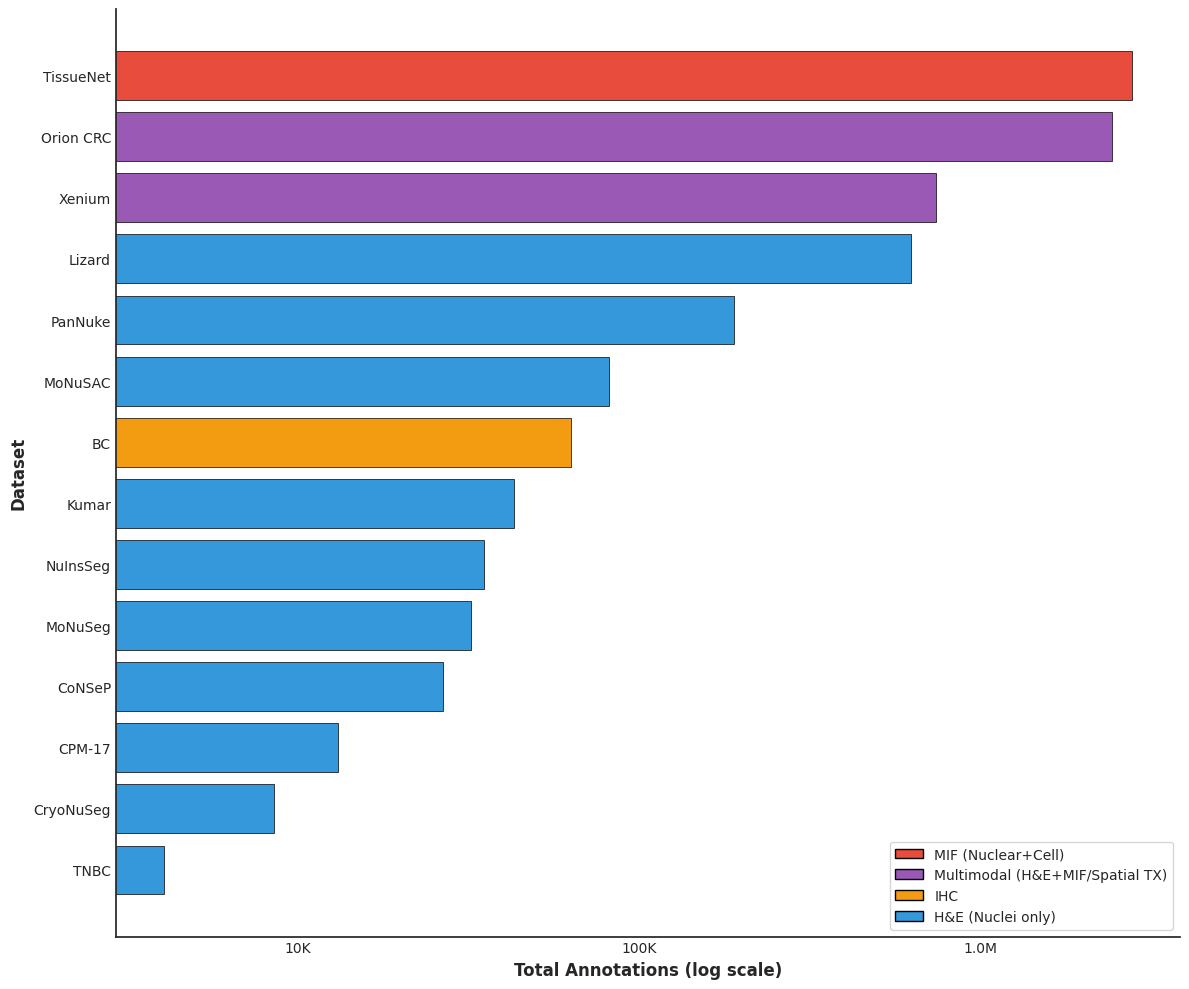

✅ Figure saved as Fig_Dataset_Annotations.pdf

Generating visualization 2: Stacked HE vs MIF breakdown...


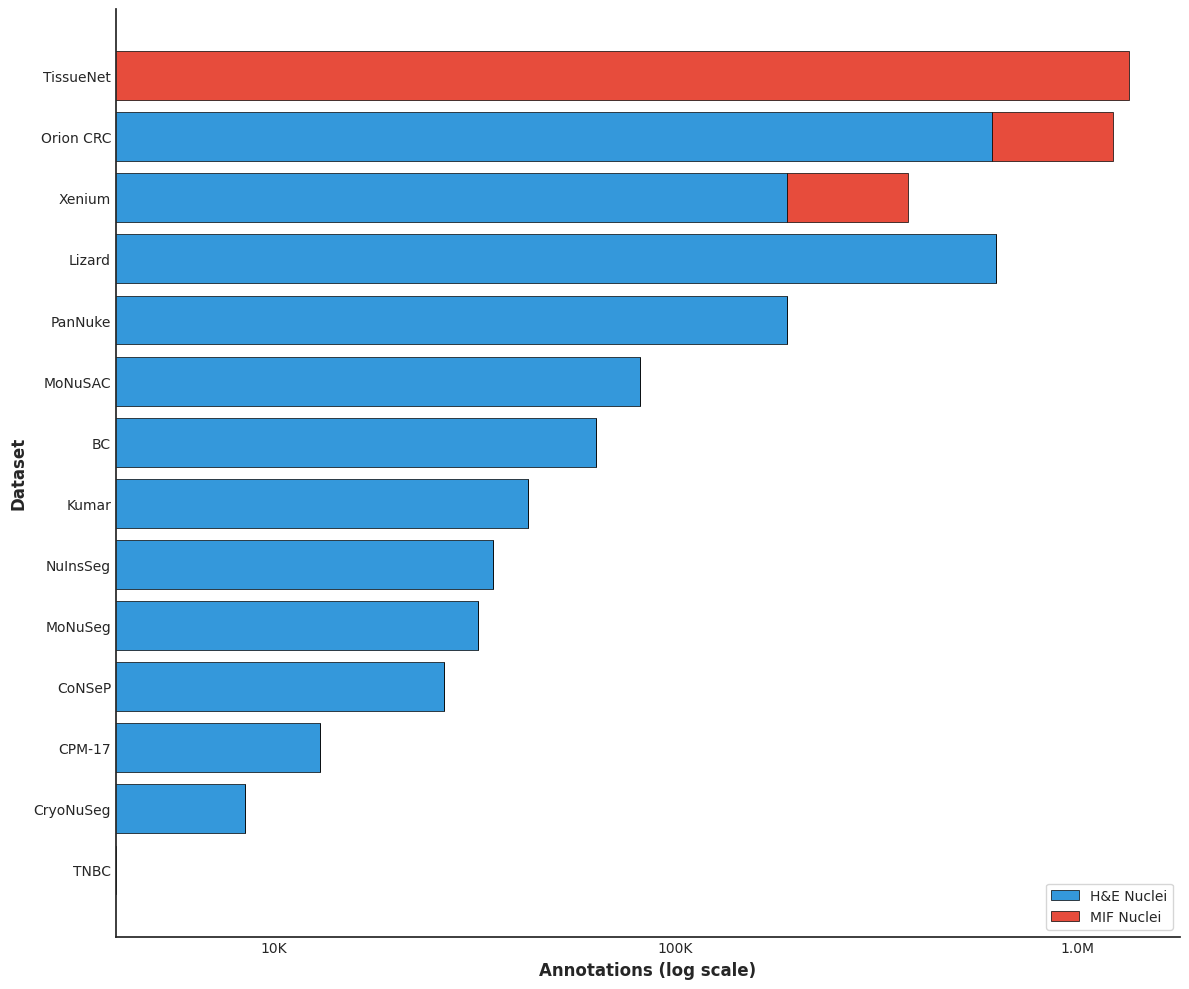

✅ Figure saved as Fig_Dataset_Annotations_Stacked.pdf


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Hardcoded dataset statistics
datasets_data = {
    'TissueNet': {'total': 2771445, 'he_nuclei': 0, 'mif_nuclei': 1343719, 'modality': 'MIF\n(Nuclear+Cell)'},
    'Orion CRC': {'total': 2420614, 'he_nuclei': 611264, 'mif_nuclei': 611264, 'modality': 'H&E + MIF\n(Nuc+Cell)'},
    'Xenium': {'total': 742848, 'he_nuclei': 189580, 'mif_nuclei': 189580, 'modality': 'Spatial TX\n(Nuc+Cell)'},
    'Lizard': {'total': 625700, 'he_nuclei': 625700, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'PanNuke': {'total': 189257, 'he_nuclei': 189257, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'MoNuSAC': {'total': 81422, 'he_nuclei': 81422, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'BC': {'total': 63215, 'he_nuclei': 63215, 'mif_nuclei': 0, 'modality': 'IHC\n(Nuclei)'},
    'Kumar': {'total': 43065, 'he_nuclei': 43065, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'NuInsSeg': {'total': 35138, 'he_nuclei': 35138, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'MoNuSeg': {'total': 32215, 'he_nuclei': 32215, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'CoNSeP': {'total': 26609, 'he_nuclei': 26609, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'CPM-17': {'total': 13077, 'he_nuclei': 13077, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'CryoNuSeg': {'total': 8488, 'he_nuclei': 8488, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
    'TNBC': {'total': 4056, 'he_nuclei': 4056, 'mif_nuclei': 0, 'modality': 'H&E\n(Nuclei)'},
}

# Create DataFrame
df = pd.DataFrame(datasets_data).T
df = df.sort_values('total', ascending=False).reset_index()
df.columns = ['Dataset', 'Total_Annotations', 'HE_Nuclei', 'MIF_Nuclei', 'Modality']

# Ensure numeric columns are integers
df['Total_Annotations'] = df['Total_Annotations'].astype(int)
df['HE_Nuclei'] = df['HE_Nuclei'].astype(int)
df['MIF_Nuclei'] = df['MIF_Nuclei'].astype(int)

# Setup plot styling
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
rcParams['pdf.fonttype'] = 42
plt.style.use('seaborn-v0_8-white')

def format_count(value):
    """Format counts as M for millions, K for thousands"""
    if value >= 1_000_000:
        return f"{value/1_000_000:.1f}M"
    elif value >= 1_000:
        return f"{value/1_000:.0f}K"
    else:
        return f"{value:.0f}"

def plot_dataset_annotations_horizontal(df, save_path="Fig_Dataset_Annotations.pdf"):
    """
    Create horizontal bar chart with modality information and logarithmic scale
    """
    # Ensure descending order (largest to smallest from top to bottom)
    df_sorted = df.sort_values('Total_Annotations', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Color coding by modality
    colors = []
    for idx, row in df_sorted.iterrows():
        if 'MIF' in row['Modality'] and 'H&E' not in row['Modality']:
            colors.append('#E74C3C')  # Red for MIF only
        elif 'H&E + MIF' in row['Modality'] or 'Spatial TX' in row['Modality']:
            colors.append('#9B59B6')  # Purple for multimodal
        elif 'IHC' in row['Modality']:
            colors.append('#F39C12')  # Orange for IHC
        else:
            colors.append('#3498DB')  # Blue for H&E only
    
    # Create horizontal bar chart with logarithmic scale
    ax.barh(df_sorted['Dataset'], df_sorted['Total_Annotations'], color=colors, 
           edgecolor='black', linewidth=0.5)
    
    # Apply logarithmic scale to x-axis
    ax.set_xscale('log')
    
    ax.set_xlabel('Total Annotations (log scale)', fontsize=12, weight='bold')
    ax.set_ylabel('Dataset', fontsize=12, weight='bold')
    
    # Format x-axis ticks with proper log scale
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format_count(x)))
    
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', edgecolor='black', label='MIF (Nuclear+Cell)'),
        Patch(facecolor='#9B59B6', edgecolor='black', label='Multimodal (H&E+MIF/Spatial TX)'),
        Patch(facecolor='#F39C12', edgecolor='black', label='IHC'),
        Patch(facecolor='#3498DB', edgecolor='black', label='H&E (Nuclei only)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Figure saved as {save_path}")

# Alternative: Stacked bar showing HE vs MIF composition
def plot_dataset_annotations_stacked(df, save_path="Fig_Dataset_Annotations_Stacked.pdf"):
    """
    Create horizontal stacked bar chart showing HE vs MIF breakdown with log scale
    """
    # Ensure descending order (largest to smallest from top to bottom)
    df_sorted = df.sort_values('Total_Annotations', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Create stacked bars
    ax.barh(df_sorted['Dataset'], df_sorted['HE_Nuclei'], label='H&E Nuclei', 
           color='#3498DB', edgecolor='black', linewidth=0.5)
    ax.barh(df_sorted['Dataset'], df_sorted['MIF_Nuclei'], left=df_sorted['HE_Nuclei'], 
           label='MIF Nuclei', color='#E74C3C', edgecolor='black', linewidth=0.5)
    
    # Apply logarithmic scale
    ax.set_xscale('log')
    
    ax.set_xlabel('Annotations (log scale)', fontsize=12, weight='bold')
    ax.set_ylabel('Dataset', fontsize=12, weight='bold')
    
    # Format x-axis ticks
    from matplotlib.ticker import FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format_count(x)))
    
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.legend(loc='lower right', fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Figure saved as {save_path}")

# Print summary
print("\n" + "="*80)
print("DATASET ANNOTATION SUMMARY")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# Generate both plots
print("\nGenerating visualization 1: All annotations by dataset with modality labels...")
plot_dataset_annotations_horizontal(df, save_path="Fig_Dataset_Annotations.pdf")

print("\nGenerating visualization 2: Stacked HE vs MIF breakdown...")
plot_dataset_annotations_stacked(df, save_path="Fig_Dataset_Annotations_Stacked.pdf")


DATASET ANNOTATION DISTRIBUTION
  Dataset  Total_Annotations  Percentage               Modality
TissueNet            2771445       39.27    MIF\n(Nuclear+Cell)
Orion CRC            2420614       34.30  H&E + MIF\n(Nuc+Cell)
   Xenium             742848       10.53 Spatial TX\n(Nuc+Cell)
   Lizard             625700        8.87          H&E\n(Nuclei)
  PanNuke             189257        2.68          H&E\n(Nuclei)
  MoNuSAC              81422        1.15          H&E\n(Nuclei)
       BC              63215        0.90          IHC\n(Nuclei)
    Kumar              43065        0.61          H&E\n(Nuclei)
 NuInsSeg              35138        0.50          H&E\n(Nuclei)
  MoNuSeg              32215        0.46          H&E\n(Nuclei)
   CoNSeP              26609        0.38          H&E\n(Nuclei)
   CPM-17              13077        0.19          H&E\n(Nuclei)
CryoNuSeg               8488        0.12          H&E\n(Nuclei)
     TNBC               4056        0.06          H&E\n(Nuclei)

TOTAL 

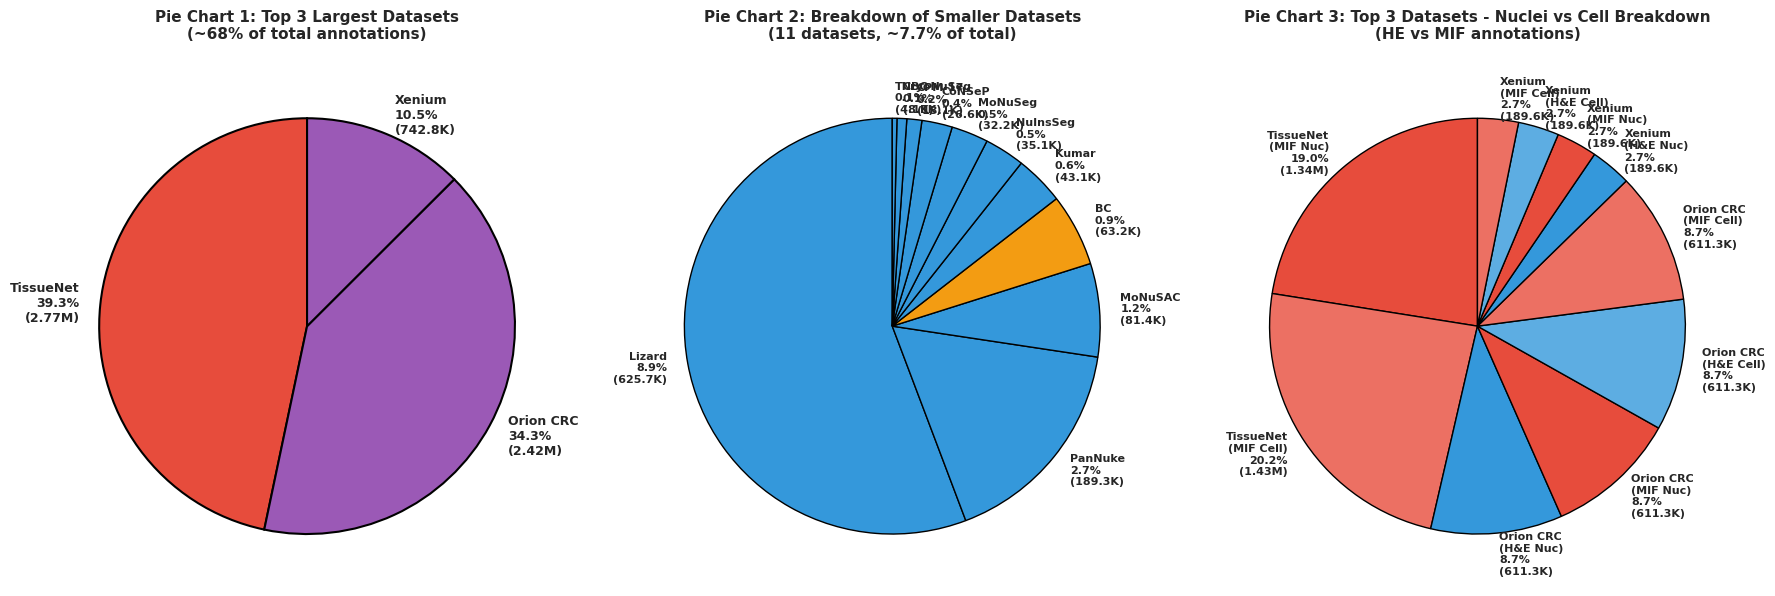

✅ Hierarchical pie charts saved as Fig_Dataset_Distribution_Hierarchical.pdf

2️⃣ Creating single comprehensive pie chart...


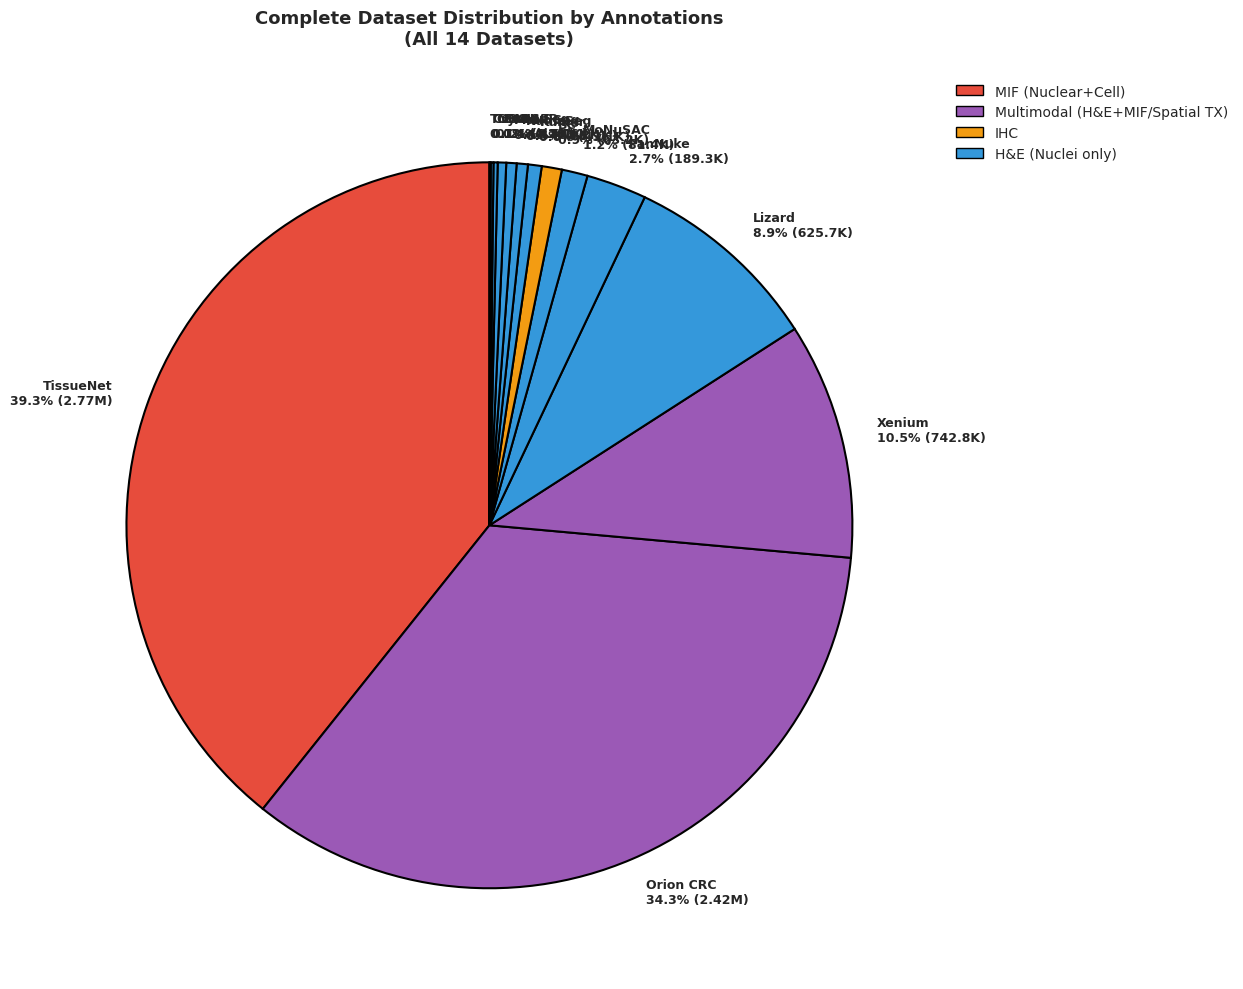

✅ Single pie chart saved as Fig_Dataset_Single_Pie.pdf

✅ All visualizations complete!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Hardcoded dataset statistics
# Based on the table: TissueNet has Nuclear + whole cell segmentation
# Orion CRC and Xenium have both nuclei and cell annotations
datasets_data = {
    'TissueNet': {'total': 2771445, 'he_nuclei': 0, 'he_cell': 0, 'mif_nuclei': 1343719, 'mif_cell': 1427726, 'modality': 'MIF\n(Nuclear+Cell)'},
    'Orion CRC': {'total': 2420614, 'he_nuclei': 611264, 'he_cell': 611264, 'mif_nuclei': 611264, 'mif_cell': 611264, 'modality': 'H&E + MIF\n(Nuc+Cell)'},
    'Xenium': {'total': 742848, 'he_nuclei': 189580, 'he_cell': 189580, 'mif_nuclei': 189580, 'mif_cell': 189580, 'modality': 'Spatial TX\n(Nuc+Cell)'},
    'Lizard': {'total': 625700, 'he_nuclei': 625700, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'PanNuke': {'total': 189257, 'he_nuclei': 189257, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'MoNuSAC': {'total': 81422, 'he_nuclei': 81422, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'BC': {'total': 63215, 'he_nuclei': 63215, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'IHC\n(Nuclei)'},
    'Kumar': {'total': 43065, 'he_nuclei': 43065, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'NuInsSeg': {'total': 35138, 'he_nuclei': 35138, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'MoNuSeg': {'total': 32215, 'he_nuclei': 32215, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'CoNSeP': {'total': 26609, 'he_nuclei': 26609, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'CPM-17': {'total': 13077, 'he_nuclei': 13077, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'CryoNuSeg': {'total': 8488, 'he_nuclei': 8488, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
    'TNBC': {'total': 4056, 'he_nuclei': 4056, 'he_cell': 0, 'mif_nuclei': 0, 'mif_cell': 0, 'modality': 'H&E\n(Nuclei)'},
}

# Create DataFrame
df = pd.DataFrame(datasets_data).T
df = df.sort_values('total', ascending=False).reset_index()
df.columns = ['Dataset', 'Total_Annotations', 'HE_Nuclei', 'HE_Cell', 'MIF_Nuclei', 'MIF_Cell', 'Modality']

# Ensure numeric columns are integers
df['Total_Annotations'] = df['Total_Annotations'].astype(int)
df['HE_Nuclei'] = df['HE_Nuclei'].astype(int)
df['HE_Cell'] = df['HE_Cell'].astype(int)
df['MIF_Nuclei'] = df['MIF_Nuclei'].astype(int)
df['MIF_Cell'] = df['MIF_Cell'].astype(int)

# Setup plot styling
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
rcParams['pdf.fonttype'] = 42
plt.style.use('seaborn-v0_8-white')

def format_count(value):
    """Format counts as M for millions, K for thousands"""
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.1f}K"
    else:
        return f"{value:.0f}"

def get_modality_color(modality):
    """Return color based on modality"""
    if 'MIF' in modality and 'H&E' not in modality:
        return '#E74C3C'  # Red for MIF only
    elif 'H&E + MIF' in modality or 'Spatial TX' in modality:
        return '#9B59B6'  # Purple for multimodal
    elif 'IHC' in modality:
        return '#F39C12'  # Orange for IHC
    else:
        return '#3498DB'  # Blue for H&E only

# Calculate percentages
total_annotations = df['Total_Annotations'].sum()
df['Percentage'] = (df['Total_Annotations'] / total_annotations * 100).round(2)

print("\n" + "="*80)
print("DATASET ANNOTATION DISTRIBUTION")
print("="*80)
print(df[['Dataset', 'Total_Annotations', 'Percentage', 'Modality']].to_string(index=False))
print(f"\nTOTAL ANNOTATIONS: {format_count(total_annotations)}")
print("="*80)

# ============================================================================
# PIE CHART 1: Top 3 datasets (largest portions)
# ============================================================================
def create_hierarchical_pie_charts(df, save_prefix="Fig_Dataset_Distribution"):
    """
    Create three pie charts:
    1. Top 3 datasets + "Others"
    2. The "Others" category broken down
    3. Optional: Further breakdown if needed
    """
    
    # Separate top 3 and rest
    top_3 = df.head(3).copy()
    rest = df.iloc[3:].copy()
    rest_total = rest['Total_Annotations'].sum()
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # ---- PIE CHART 1: Top 3 only (empty space for rest) ----
    ax1 = axes[0]
    
    pie1_labels = list(top_3['Dataset'].values)
    pie1_values = list(top_3['Total_Annotations'].values)
    pie1_colors = [get_modality_color(mod) for mod in top_3['Modality'].values]
    
    # Calculate percentages for labels
    pie1_percentages = [v / total_annotations * 100 for v in pie1_values]
    pie1_labels_with_pct = [f"{label}\n{pct:.1f}%\n({format_count(val)})" 
                             for label, pct, val in zip(pie1_labels, pie1_percentages, pie1_values)]
    
    wedges1, texts1, autotexts1 = ax1.pie(
        pie1_values, 
        labels=pie1_labels_with_pct,
        colors=pie1_colors,
        autopct='',
        startangle=90,
        textprops={'fontsize': 9, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
    )
    
    ax1.set_title('Pie Chart 1: Top 3 Largest Datasets\n(~68% of total annotations)', 
                  fontsize=11, weight='bold', pad=20)
    
    # ---- PIE CHART 2: "Others" breakdown (remaining 11 datasets) ----
    ax2 = axes[1]
    
    pie2_labels = rest['Dataset'].values
    pie2_values = rest['Total_Annotations'].values
    pie2_colors = [get_modality_color(mod) for mod in rest['Modality'].values]
    
    # Calculate percentages
    pie2_percentages = [v / total_annotations * 100 for v in pie2_values]
    pie2_labels_with_pct = [f"{label}\n{pct:.1f}%\n({format_count(val)})" 
                             for label, pct, val in zip(pie2_labels, pie2_percentages, pie2_values)]
    
    wedges2, texts2, autotexts2 = ax2.pie(
        pie2_values,
        labels=pie2_labels_with_pct,
        colors=pie2_colors,
        autopct='',
        startangle=90,
        textprops={'fontsize': 8, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )
    
    ax2.set_title('Pie Chart 2: Breakdown of Smaller Datasets\n(11 datasets, ~7.7% of total)', 
                  fontsize=11, weight='bold', pad=20)
    
    # ---- PIE CHART 3: Top 3 breakdown (showing Nuclei vs Cell) ----
    ax3 = axes[2]
    
    pie3_labels = []
    pie3_values = []
    pie3_colors = []
    
    for idx, row in top_3.iterrows():
        dataset = row['Dataset']
        he_nuc = row['HE_Nuclei']
        he_cell = row['HE_Cell']
        mif_nuc = row['MIF_Nuclei']
        mif_cell = row['MIF_Cell']
        modality = row['Modality']
        
        # Add nuclei annotations
        if he_nuc > 0:
            pie3_labels.append(f"{dataset}\n(H&E Nuc)")
            pie3_values.append(he_nuc)
            pie3_colors.append('#3498DB')
        
        if mif_nuc > 0:
            pie3_labels.append(f"{dataset}\n(MIF Nuc)")
            pie3_values.append(mif_nuc)
            pie3_colors.append('#E74C3C')
        
        # Add cell annotations
        if he_cell > 0:
            pie3_labels.append(f"{dataset}\n(H&E Cell)")
            pie3_values.append(he_cell)
            pie3_colors.append('#5DADE2')
        
        if mif_cell > 0:
            pie3_labels.append(f"{dataset}\n(MIF Cell)")
            pie3_values.append(mif_cell)
            pie3_colors.append('#EC7063')
    
    # Calculate percentages
    pie3_percentages = [v / total_annotations * 100 for v in pie3_values]
    pie3_labels_with_pct = [f"{label}\n{pct:.1f}%\n({format_count(val)})" 
                             for label, pct, val in zip(pie3_labels, pie3_percentages, pie3_values)]
    
    wedges3, texts3, autotexts3 = ax3.pie(
        pie3_values,
        labels=pie3_labels_with_pct,
        colors=pie3_colors,
        autopct='',
        startangle=90,
        textprops={'fontsize': 8, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )
    
    ax3.set_title('Pie Chart 3: Top 3 Datasets - Nuclei vs Cell Breakdown\n(HE vs MIF annotations)', 
                  fontsize=11, weight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_Hierarchical.pdf", format='pdf', transparent=True, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ Hierarchical pie charts saved as {save_prefix}_Hierarchical.pdf")

# ============================================================================
# Alternative: Single large pie with color-coded modality
# ============================================================================
def create_single_pie_with_legend(df, save_path="Fig_Dataset_Single_Pie.pdf"):
    """
    Create a single comprehensive pie chart with all datasets and legend
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    labels = df['Dataset'].values
    values = df['Total_Annotations'].values
    colors = [get_modality_color(mod) for mod in df['Modality'].values]
    
    # Create labels with percentages and counts
    percentages = [v / total_annotations * 100 for v in values]
    labels_with_info = [f"{label}\n{pct:.1f}% ({format_count(val)})" 
                        for label, pct, val in zip(labels, percentages, values)]
    
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels_with_info,
        colors=colors,
        autopct='',
        startangle=90,
        textprops={'fontsize': 9, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
    )
    
    ax.set_title('Complete Dataset Distribution by Annotations\n(All 14 Datasets)', 
                 fontsize=13, weight='bold', pad=20)
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', edgecolor='black', label='MIF (Nuclear+Cell)'),
        Patch(facecolor='#9B59B6', edgecolor='black', label='Multimodal (H&E+MIF/Spatial TX)'),
        Patch(facecolor='#F39C12', edgecolor='black', label='IHC'),
        Patch(facecolor='#3498DB', edgecolor='black', label='H&E (Nuclei only)'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Single pie chart saved as {save_path}")

# Generate all visualizations
print("\n📊 Generating visualizations...")
print("\n1️⃣ Creating hierarchical pie charts (3 levels)...")
create_hierarchical_pie_charts(df)

print("\n2️⃣ Creating single comprehensive pie chart...")
create_single_pie_with_legend(df)

print("\n✅ All visualizations complete!")

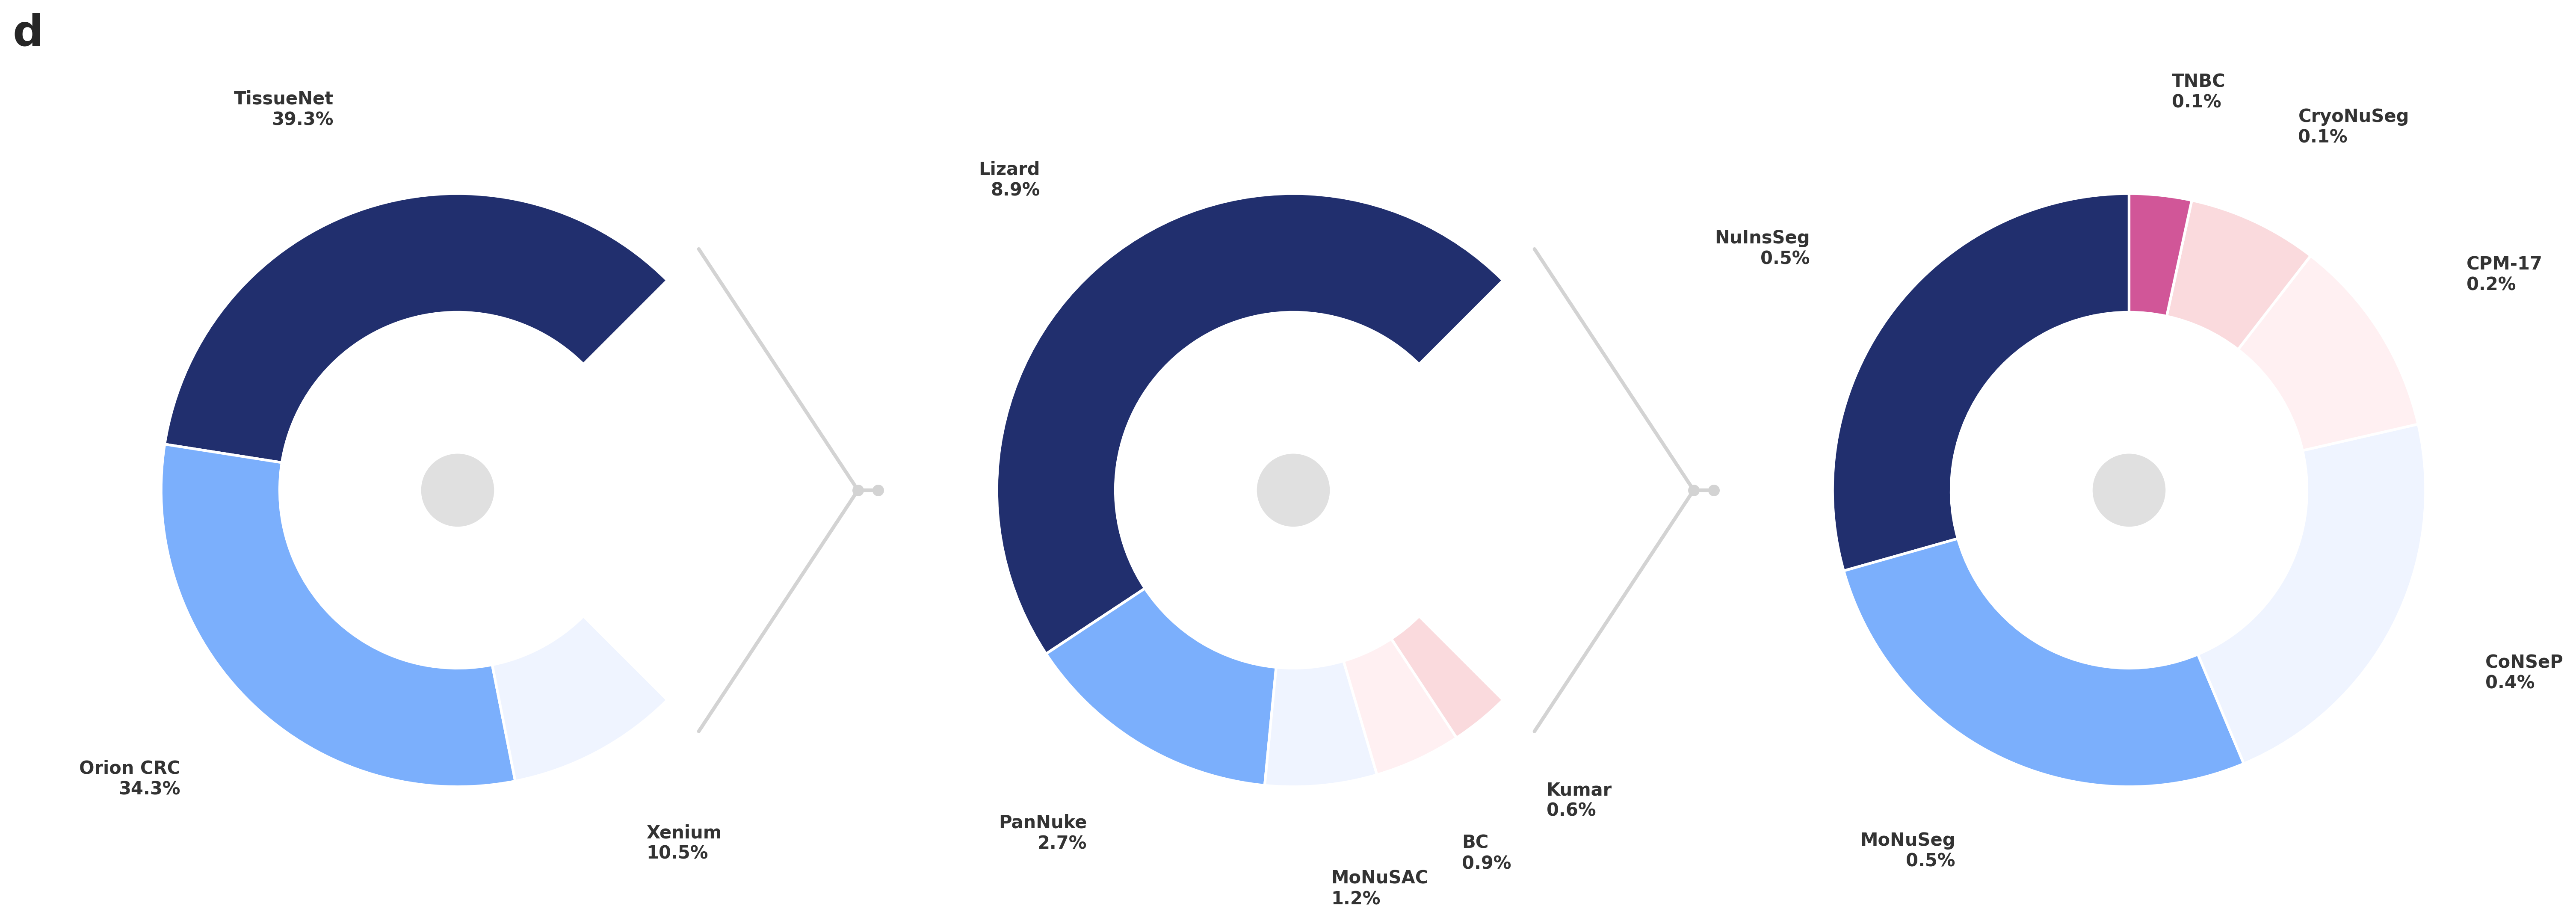

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# ---------------------------------------------------------
# 1. DATA SETUP
# ---------------------------------------------------------

# Your raw data dictionary
datasets_data = {
    'TissueNet': {'total': 2771445},
    'Orion CRC': {'total': 2420614},
    'Xenium': {'total': 742848},
    'Lizard': {'total': 625700},
    'PanNuke': {'total': 189257},
    'MoNuSAC': {'total': 81422},
    'BC': {'total': 63215},
    'Kumar': {'total': 43065},
    'NuInsSeg': {'total': 35138},
    'MoNuSeg': {'total': 32215},
    'CoNSeP': {'total': 26609},
    'CPM-17': {'total': 13077},
    'CryoNuSeg': {'total': 8488},
    'TNBC': {'total': 4056},
}

# 1. Calculate Global Total
global_total = sum(d['total'] for d in datasets_data.values())

# 2. Process data into a sorted list of dicts: {'label': Name, 'value': Percentage}
processed_list = []
for name, info in datasets_data.items():
    perc = (info['total'] / global_total) * 100
    processed_list.append({'label': name, 'value': perc})

# 3. Sort from Largest to Smallest
processed_list.sort(key=lambda x: x['value'], reverse=True)

# 4. Distribute into 3 Groups (Head, Middle, Tail)
# You can adjust these slice indices [0:3], [3:8], [8:] if you want to move items between charts.
group1_data = processed_list[0:3]   # Top 3 largest (TissueNet, Orion, Xenium)
group2_data = processed_list[3:8]   # Next 5 (Lizard -> Kumar)
group3_data = processed_list[8:]    # The rest (Smallest)

chart_data = [
    # Chart 1: The "Head" (Left) -> C-Shape
    {
        "data": group1_data,
        "is_full_circle": False
    },
    # Chart 2: The "Middle" (Center) -> C-Shape
    {
        "data": group2_data,
        "is_full_circle": False
    },
    # Chart 3: The "Tail" (Right) -> FULL CIRCLE
    {
        "data": group3_data,
        "is_full_circle": True 
    }
]

# Color Palette (Extended slightly to handle more slices if needed)
colors = [
    "#212F6E",  # Dark Blue
    "#7BAFFC",  # Medium Blue
    "#EFF4FF",  # Light Blue/White
    "#FFF0F2",  # Pale Pink
    "#FADADD",  # Light Pink
    "#D15698",  # Magenta
    "#C14588",  # Darker Pink
    "#A13578"   # Purple-ish
]

# ---------------------------------------------------------
# 2. PLOTTING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plt.subplots_adjust(wspace=0.3) 

donut_width = 0.4

for i, ax in enumerate(axes):
    group = chart_data[i]
    vals = [item['value'] for item in group['data']]
    labels = [item['label'] for item in group['data']]
    
    # --- LOGIC FOR SHAPE ---
    if not group['is_full_circle']:
        # C-SHAPE LOGIC (Gap on Right)
        total_visible = sum(vals)
        gap_size = total_visible / 3.0  # Gap is 1/4 of total circle
        
        plot_vals = vals + [gap_size]
        # Ensure we have enough colors
        current_colors = colors[:len(vals)] + [(0,0,0,0)] 
        
        # Start at 45 degrees to center the gap on the right
        start_angle = 45 
        
    else:
        # FULL CIRCLE LOGIC
        plot_vals = vals
        current_colors = colors[:len(vals)]
        
        # Start at Top
        start_angle = 90

    # Draw the Pie
    wedges, _ = ax.pie(
        plot_vals, 
        colors=current_colors, 
        startangle=start_angle,
        counterclock=True,
        wedgeprops={'width': donut_width, 'edgecolor': 'white', 'linewidth': 1.5},
        radius=1
    )
    
    # Add Center Dot
    ax.add_patch(plt.Circle((0, 0), 0.12, color='#E0E0E0', zorder=10))

    # --- LABELS ---
    num_labels = len(labels)
    for j in range(num_labels):
        w = wedges[j]
        ang = (w.theta2 - w.theta1)/2. + w.theta1
        
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        
        # Push labels outward
        dist = 1.35
        
        # Horizontal alignment based on side
        ha = "left" if x > 0 else "right"
        
        # Label Text: Name + formatted percentage
        lbl_text = f"{labels[j]}\n{vals[j]:.1f}%"
        
        ax.text(x*dist, y*dist, lbl_text, 
                ha=ha, va='center', fontsize=10, fontweight='bold', color='#333')

# ---------------------------------------------------------
# 3. CONNECTING BRACKETS (Left -> Right)
# ---------------------------------------------------------
def draw_connector(ax_left, ax_right):
    # Bracket coordinates (Right side of Left Chart)
    x_top, y_top = 1.15 * np.cos(np.deg2rad(45)), 1.15 * np.sin(np.deg2rad(45))
    x_bot, y_bot = 1.15 * np.cos(np.deg2rad(-45)), 1.15 * np.sin(np.deg2rad(-45))
    x_tip, y_tip = 1.35, 0
    
    # Draw Bracket Lines
    ax_left.plot([x_top, x_tip, x_bot], [y_top, y_tip, y_bot], color='lightgray', lw=2, clip_on=False)
    
    # Connection Line to Next Chart
    con = patches.ConnectionPatch(
        xyA=(x_tip, 0), coordsA=ax_left.transData,
        xyB=(-1.4, 0), coordsB=ax_right.transData,
        color='lightgray', lw=2, zorder=0
    )
    fig.add_artist(con)
    
    # Add dots
    ax_left.scatter([x_tip], [0], color='lightgray', s=30, clip_on=False)
    ax_right.scatter([-1.4], [0], color='lightgray', s=30, clip_on=False)

# Draw connections
draw_connector(axes[0], axes[1])
draw_connector(axes[1], axes[2])

# Title 'd' (Optional, kept from original)
axes[0].text(-1.5, 1.5, "d", fontsize=24, fontweight='bold')

plt.tight_layout()
plt.show()

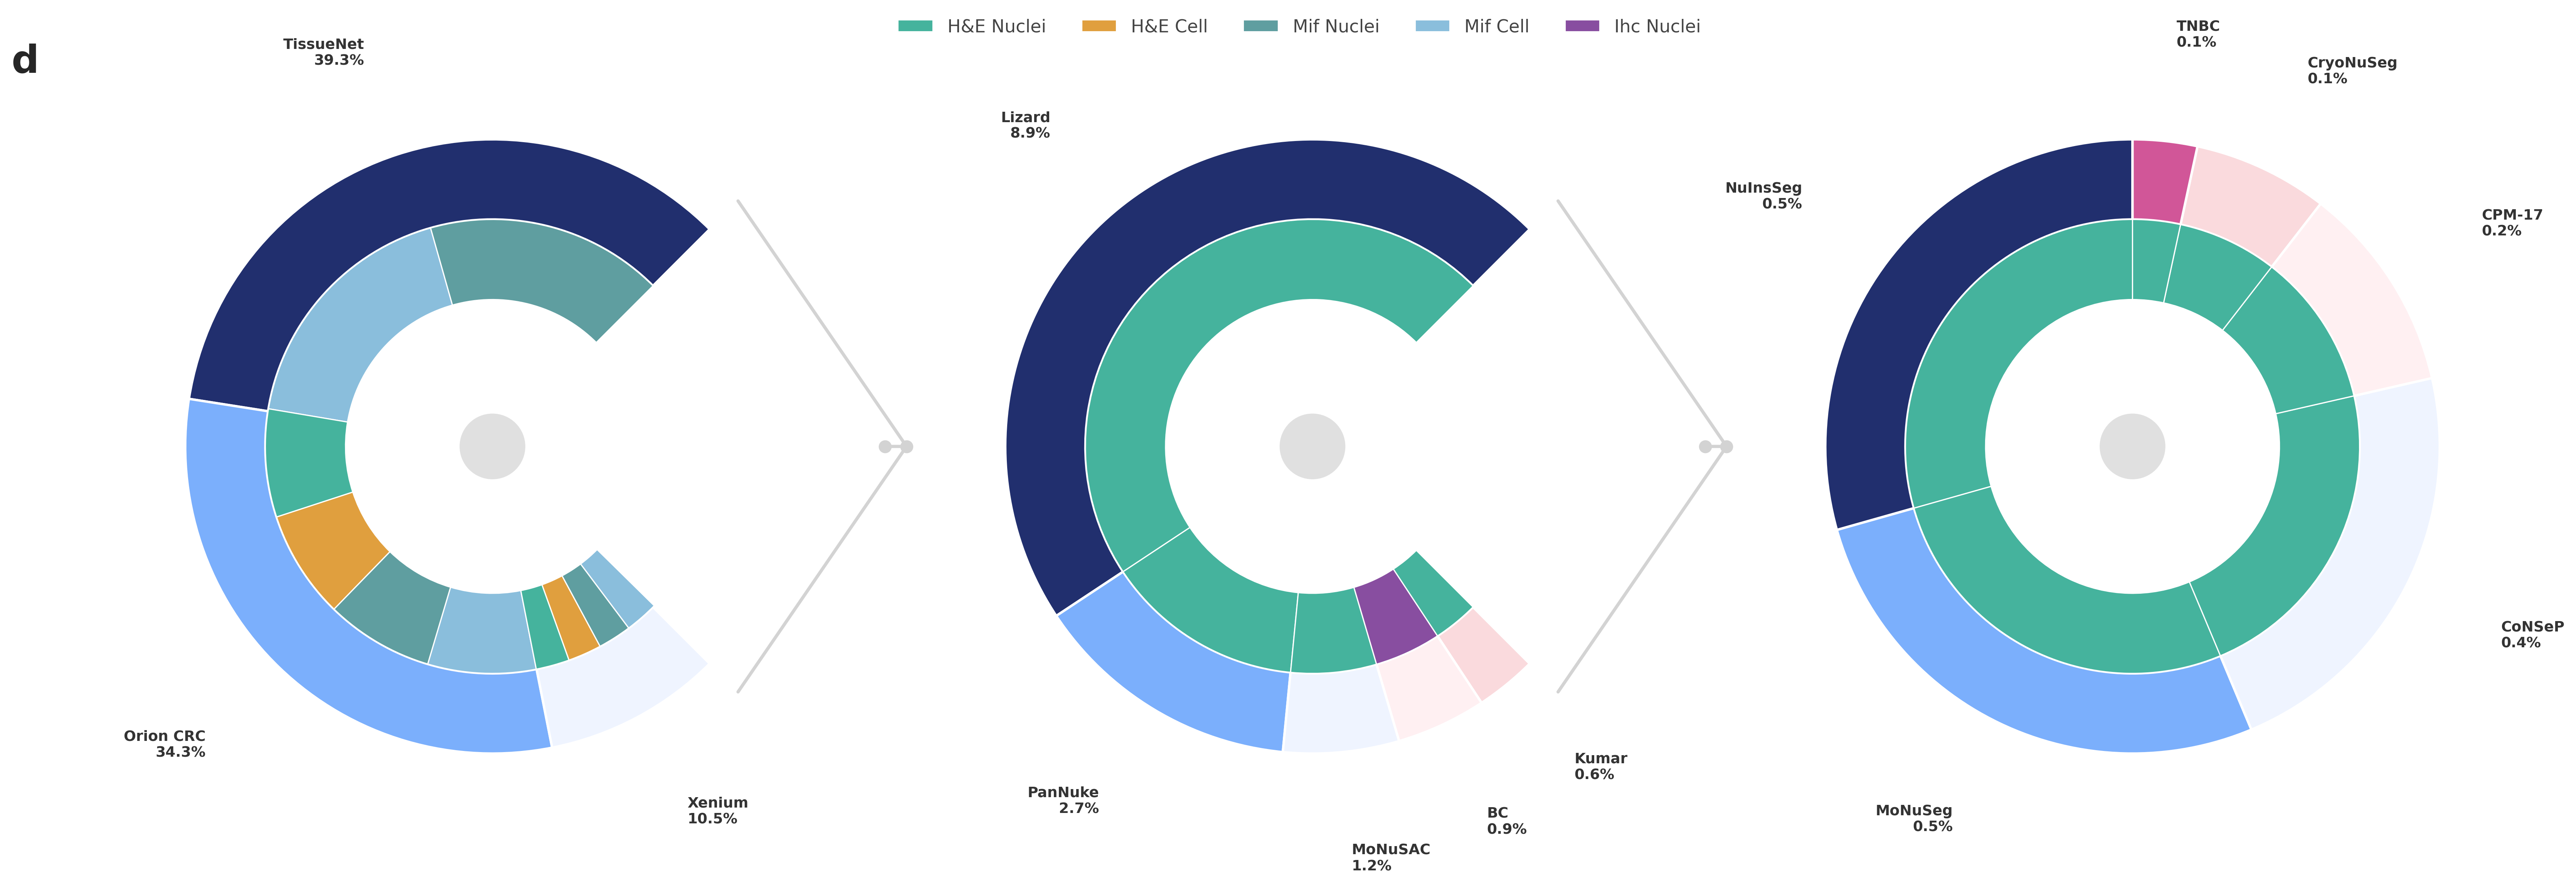

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# ---------------------------------------------------------
# 1. DATA SETUP
# ---------------------------------------------------------
datasets_data = {
    'TissueNet': {'total': 2771445, 'breakdown': {'mif_nuclei': 1343719, 'mif_cell': 1427726}},
    'Orion CRC': {'total': 2420614, 'breakdown': {'he_nuclei': 611264, 'he_cell': 611264, 'mif_nuclei': 611264, 'mif_cell': 611264}},
    # Updated Xenium entry with HE and MIF components
    'Xenium':    {'total': 742848,  'breakdown': {'he_nuclei': 189580, 'he_cell': 189580, 'mif_nuclei': 189580, 'mif_cell': 189580}},
    'Lizard':    {'total': 625700,  'breakdown': {'he_nuclei': 625700}},
    'PanNuke':   {'total': 189257,  'breakdown': {'he_nuclei': 189257}},
    'MoNuSAC':   {'total': 81422,   'breakdown': {'he_nuclei': 81422}},
    'BC':        {'total': 63215,   'breakdown': {'ihc_nuclei': 63215}}, 
    'Kumar':     {'total': 43065,   'breakdown': {'he_nuclei': 43065}},
    'NuInsSeg':  {'total': 35138,   'breakdown': {'he_nuclei': 35138}},
    'MoNuSeg':   {'total': 32215,   'breakdown': {'he_nuclei': 32215}},
    'CoNSeP':    {'total': 26609,   'breakdown': {'he_nuclei': 26609}},
    'CPM-17':    {'total': 13077,   'breakdown': {'he_nuclei': 13077}},
    'CryoNuSeg': {'total': 8488,    'breakdown': {'he_nuclei': 8488}},
    'TNBC':      {'total': 4056,    'breakdown': {'he_nuclei': 4056}},
}

# --- COLOR DEFINITIONS ---

# 1. OUTER RING (Standard Palette)
outer_colors_palette = [
    "#212F6E",  # Dark Blue
    "#7BAFFC",  # Medium Blue
    "#EFF4FF",  # Light Blue/White
    "#FFF0F2",  # Pale Pink
    "#FADADD",  # Light Pink
    "#D15698",  # Magenta
    "#C14588",  # Darker Pink
    "#A13578"   # Purple-ish
]

# 2. INNER RING (Refined Elegance)
subtype_colors_map = {
    'he_nuclei':  '#45B39D',  # Elegant Muted Teal 
    'he_cell':    '#E09F3E',  # Ochre
    'mif_nuclei': '#5F9EA0',  # Cadet Blue
    'mif_cell':   '#8ABEDC',  # Sky Blue
    'ihc_nuclei': '#884EA0',  # Purple (IHC)
}

# Process Data
global_total = sum(d['total'] for d in datasets_data.values())
processed_list = []
for name, info in datasets_data.items():
    perc = (info['total'] / global_total) * 100
    processed_list.append({
        'label': name, 
        'value': perc, 
        'raw_total': info['total'],
        'breakdown': info['breakdown']
    })

processed_list.sort(key=lambda x: x['value'], reverse=True)

# Split Groups
chart_data = [
    {"data": processed_list[0:3], "is_full_circle": False}, # Head
    {"data": processed_list[3:8], "is_full_circle": False}, # Middle
    {"data": processed_list[8:],  "is_full_circle": True }  # Tail
]

# ---------------------------------------------------------
# 2. PLOTTING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
plt.subplots_adjust(wspace=0.35, top=0.85, bottom=0.1) 

outer_radius = 1.15
inner_radius = 0.85
donut_width = 0.3

for i, ax in enumerate(axes):
    group = chart_data[i]
    
    # --- DATA PREP ---
    outer_vals = [item['value'] for item in group['data']]
    outer_labels = [item['label'] for item in group['data']]
    
    # Flatten Inner Data
    inner_vals = []
    inner_cols = []
    for item in group['data']:
        scale_factor = item['value'] / item['raw_total']
        for subtype, count in item['breakdown'].items():
            if count > 0:
                inner_vals.append(count * scale_factor)
                inner_cols.append(subtype_colors_map.get(subtype, '#999999'))
    
    # --- SHAPE LOGIC ---
    base_colors = outer_colors_palette[:len(outer_vals)]
    
    if not group['is_full_circle']:
        # C-Shape
        total_visible = sum(outer_vals)
        gap_size = total_visible / 3.0
        
        plot_outer_vals = outer_vals + [gap_size]
        plot_inner_vals = inner_vals + [gap_size]
        
        current_outer_colors = base_colors + [(0,0,0,0)]
        current_inner_colors = inner_cols + [(0,0,0,0)]
        
        start_angle = 45 
    else:
        # Full Circle
        plot_outer_vals = outer_vals
        plot_inner_vals = inner_vals
        
        current_outer_colors = base_colors
        current_inner_colors = inner_cols
        
        start_angle = 90
        
    # 1. DRAW OUTER RING
    wedges, _ = ax.pie(
        plot_outer_vals, 
        colors=current_outer_colors, 
        startangle=start_angle,
        radius=outer_radius,
        wedgeprops={'width': donut_width, 'edgecolor': 'white', 'linewidth': 1.5}
    )

    # 2. DRAW INNER RING
    ax.pie(
        plot_inner_vals, 
        colors=current_inner_colors, 
        startangle=start_angle,
        radius=inner_radius,
        wedgeprops={'width': donut_width, 'edgecolor': 'white', 'linewidth': 0.75}
    )
    
    # 3. ADD CENTER DOT (Restored)
    # Adding a small circle in the center for the "connected" look
    ax.add_patch(plt.Circle((0, 0), 0.12, color='#E0E0E0', zorder=10))

    # --- LABELS ---
    for j, w in enumerate(wedges):
        if j >= len(outer_labels): continue 
        
        ang = (w.theta2 - w.theta1)/2. + w.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        ha = "left" if x > 0 else "right"
        dist = 1.55
        
        label_str = f"{outer_labels[j]}\n{outer_vals[j]:.1f}%"
        
        if (w.theta2 - w.theta1) > 4 or group['is_full_circle']: 
             ax.text(x*dist, y*dist, label_str, ha=ha, va='center', 
                     fontsize=9, color='#333333', fontweight='bold')

# ---------------------------------------------------------
# 3. CONNECTING BRACKETS (Restored Logic)
# ---------------------------------------------------------
def draw_connector(ax_left, ax_right):
    # Calculate coords based on current radius
    scale = 1.30 
    tip_scale = 1.55
    
    # Bracket coordinates (Right side of Left Chart)
    x_top, y_top = scale * np.cos(np.deg2rad(45)), scale * np.sin(np.deg2rad(45))
    x_bot, y_bot = scale * np.cos(np.deg2rad(-45)), scale * np.sin(np.deg2rad(-45))
    x_tip, y_tip = tip_scale, 0
    
    # Draw Bracket Lines
    ax_left.plot([x_top, x_tip, x_bot], [y_top, y_tip, y_bot], color='lightgray', lw=2, clip_on=False)
    
    # Connection Line to Next Chart
    con = patches.ConnectionPatch(
        xyA=(x_tip, 0), coordsA=ax_left.transData,
        xyB=(-1.6, 0), coordsB=ax_right.transData,
        color='lightgray', lw=2, zorder=0
    )
    fig.add_artist(con)
    
    # Add dots at the connection points
    ax_left.scatter([x_tip], [0], color='lightgray', s=50, clip_on=False, zorder=5)
    ax_right.scatter([-1.6], [0], color='lightgray', s=50, clip_on=False, zorder=5)

# Draw connections
draw_connector(axes[0], axes[1])
draw_connector(axes[1], axes[2])

# ---------------------------------------------------------
# 4. LEGEND & TITLE
# ---------------------------------------------------------
legend_elements = [
    patches.Patch(facecolor=color, edgecolor='white', label=label.replace('_', ' ').replace('mif', 'MIF').replace('he', 'H&E').replace('ihc', 'IHC').title())
    for label, color in subtype_colors_map.items()
]
leg = fig.legend(handles=legend_elements, loc='upper center', ncol=5, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 0.98))
for text in leg.get_texts(): text.set_color('#444444')

axes[0].text(-1.8, 1.4, "d", fontsize=24, fontweight='bold')

plt.tight_layout()

# SAVE AS PDF
# bbox_inches='tight' ensures labels aren't cut off
# transparent=True removes the white background
plt.savefig('dataset_distribution.pdf', format='pdf', bbox_inches='tight', transparent=True)

plt.show()